## Librerias

In [477]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [478]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [479]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [480]:
# Cuantos partidos se jugaron?
# Completar
mundial.shape[0]

64

In [481]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.columns

Index(['match_no', 'day_of_week', 'date', 'hour', 'venue', 'referee', 'group',
       '1', '2', 'attendance', '1_xg', '2_xg', '1_poss', '2_poss', '1_goals',
       '2_goals', 'score', '1_attempts', '2_attempts', '1_conceded',
       '2_conceded', '1_goal_inside_penalty_area',
       '2_goal_inside_penalty_area', '1_goal_outside_penalty_area',
       '2_goal_outside_penalty_area', '1_ontarget', '2_ontarget',
       '1_offtarget', '2_offtarget', '1_attempts_inside_penalty_area',
       '2_attempts_inside_penalty_area', '1_attempts_outside_penalty_area',
       '2_attempts_outside_penalty_area', '1_yellow_cards', '2_yellow_cards',
       '1_red_cards', '2_red_cards', 'faul_against_1', 'faul_against_2',
       '1_offsides', '2_offsides', '1_passes', '2_passes',
       '1_passes_compeletd', '2_passes_compeletd', '1_corners', '2_corners',
       '1_free_kicks', '2_free_kicks', '1_panelties_scored',
       '2_panelties_scored', '1_goal_prevented', '2_goal_prevented',
       '1_own_goal', '2_o

## Analisis

### Primera Parte

In [482]:
# Cuantas selecciones participaron?
# Completar
mundial["1"].nunique()

32

In [483]:
# Cuantas fases tiene el mundial?
# Completar
mundial["group"].nunique()

13

In [484]:
# Cual fue la "attendance" promedio por partido?
# Completar
mundial["attendance"].mean()

np.float64(53191.4375)

In [485]:
# Cual fue el partido con mas diferencia de goles?
# Completar
columnas_selecciones = ["1", "2"]
mundial.loc[(mundial["1_goals"] - mundial["2_goals"]).abs().idxmax(), columnas_selecciones]

1         SPAIN
2    COSTA RICA
Name: 10, dtype: str

In [486]:
# Cual es la selección que mas penales metió?
# Completar
mundial.groupby("1")["1_panelties_scored"].sum().idxmax()

'ARGENTINA'

In [487]:
# Cual es la selección que mas penales le hicieron?
# Completar
mundial.groupby("2")["1_panelties_scored"].sum().idxmax()

'FRANCE'

### Segunda Parte

In [488]:
equipo : str = "ARGENTINA"

In [489]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar
columnas=["1", "2"]
filtroLocal : pd.Series = mundial["1"] == equipo
print(mundial.loc[filtroLocal, columnas])

            1             2
4   ARGENTINA  SAUDI ARABIA
23  ARGENTINA        MEXICO
49  ARGENTINA     AUSTRALIA
60  ARGENTINA       CROATIA
63  ARGENTINA        FRANCE


In [490]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar
columnas=["1", "2"]
filtroLocal : pd.Series = mundial["2"] == equipo
print(mundial.loc[filtroLocal, columnas])

              1          2
38       POLAND  ARGENTINA
57  NETHERLANDS  ARGENTINA


In [491]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar
columnas=["1", "2"]
filtroLocal : pd.Series = mundial.loc[(mundial["1"] == equipo) | (mundial["2"] == equipo), columnas]
print(filtroLocal)

              1             2
4     ARGENTINA  SAUDI ARABIA
23    ARGENTINA        MEXICO
38       POLAND     ARGENTINA
49    ARGENTINA     AUSTRALIA
57  NETHERLANDS     ARGENTINA
60    ARGENTINA       CROATIA
63    ARGENTINA        FRANCE


In [492]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles : int = mundial.loc[mundial["1"] == equipo, "1_goals"].sum() + mundial.loc[mundial["2"] == equipo, "2_goals"].sum()
print(goles)

15


In [493]:
# Cuantos goles hizo el equipo en promedio
# Completar
partidos_jugados : int = mundial.loc[(mundial["1"] == equipo) | (mundial["2"] == equipo)].shape[0]
goles_promedio : float = goles / partidos_jugados
print(goles_promedio)

2.142857142857143


In [494]:
# Cuantos partidos gano el equipo
# Completar
partidos_ganados : int = mundial.loc[((mundial["1"] == equipo) & (mundial["1_goals"] > mundial["2_goals"])) | ((mundial["2"] == equipo) & (mundial["2_goals"] > mundial["1_goals"]))].shape[0]
print(partidos_ganados)

    

4


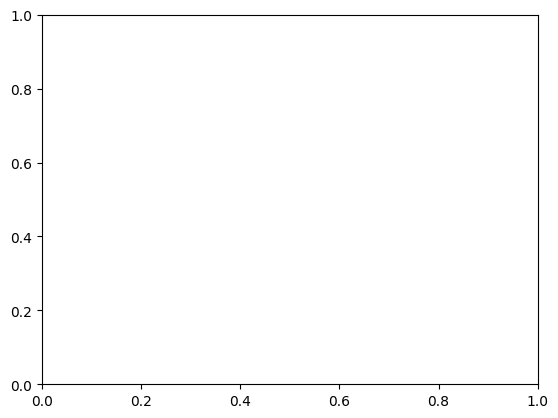

In [495]:
# Graficar los goles hechos por el equipo en cada partido

fig, ax = plt.subplots()
# Completar

### Tercera Parte

In [496]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar

equipos = 
goles = 

SyntaxError: invalid syntax (210265308.py, line 4)

In [ ]:
# Graficar los goles por equipo en todo el mundial

fig, ax = plt.subplots()
# Completar

In [ ]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar

In [ ]:
# Por cada partido, cual fue la diferencia de goles?
# Completar

In [ ]:
# Por cada partido, cual fue el equipo que gano?
# Completar

In [ ]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar

### Tercera Parte

In [ ]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar